# CNN + Temporal Attention — Key Classifier

Classifies MIDI files into one of **24 musical keys** (12 major + 12 minor)  
using pre-saved piano-roll spectrograms as input.

| Stage | Detail |
|-------|--------|
| Input | `piano_roll/` `.npz` files — shape `(128, T)`, uint8 velocity 0–127 |
| Target | `key_name` column from `lmd_full_metadata.csv` (24 classes) |
| Architecture | 3-block CNN → temporal self-attention → global avg pool → FC |
| Class imbalance | `WeightedRandomSampler` (C major ≈ 62 % of labeled data) |

Pipeline context: Stage 3 of the LMD processing pipeline.  
Run after `process_midi.ipynb` and `midi_to_spectrogram.ipynb`.

In [21]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

## 1. Configuration

In [22]:
SCRIPTS_DIR       = Path(os.path.abspath(''))
PROJECT_DIR       = SCRIPTS_DIR.parent
METADATA_CSV      = PROJECT_DIR / 'data' / 'processed_data' / 'lmd_full_metadata.csv'
PIANO_ROLL_DIR    = PROJECT_DIR / 'data' / 'processed_data' / 'spectrograms' / 'piano_roll'
BALANCED_ROLL_DIR = PROJECT_DIR / 'data' / 'processed_data' / 'spectrograms' / 'piano_roll_balanced'
MODEL_SAVE_PATH   = PROJECT_DIR / 'data' / 'processed_data' / 'cnn_attention_key.pt'

# ── Balancing ─────────────────────────────────────────────────────────────────
BALANCE_DATASET  = True    # pitch-shift augment + undersample to TARGET_PER_CLASS
TARGET_PER_CLASS = 2_500   # desired samples per class after balancing

# ── Model / training hyperparameters ─────────────────────────────────────────
SEGMENT_LEN     = 512   # frames per sample  (100 fps → ~5.12 s)
N_PITCH         = 128   # piano-roll pitch dimension
D_MODEL         = 256   # attention hidden dimension
N_HEADS         = 4     # number of attention heads
BATCH_SIZE      = 64
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
N_EPOCHS        = 30
PATIENCE        = 5     # early-stopping patience (val-loss)
MIN_CLASS_COUNT = 0     # keep all 24 classes; balancing handles class imbalance

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device (MPS → CUDA → CPU) ─────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

N_WORKERS = min(8, os.cpu_count())
print(f'Device: {DEVICE}   DataLoader workers: {N_WORKERS}')

Device: mps   DataLoader workers: 8


## 2. Load Metadata & Label Encoding

In [23]:
df = pd.read_csv(METADATA_CSV, parse_dates=False)

# Keep only rows that have a key label AND whose .npz file exists on disk
df = df[df['key_name'].notna()].copy()
df['stem']     = df['file'].str[:-4]   # strip '.mid'
df['npz_path'] = df['stem'].apply(lambda s: str(PIANO_ROLL_DIR / f'{s}.npz'))
df = df[df['npz_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'Labeled files with .npz present : {len(df):,}')

# Duration filter (consistent with Stage 2)
df = df[df['duration_s'] <= 300].reset_index(drop=True)
print(f'After duration filter (<=300 s) : {len(df):,}')

# Drop rare keys — need at least MIN_CLASS_COUNT labeled samples to train on a class
key_counts = df['key_name'].value_counts()
keep_keys  = key_counts[key_counts >= MIN_CLASS_COUNT].index
dropped    = key_counts[key_counts < MIN_CLASS_COUNT]
df = df[df['key_name'].isin(keep_keys)].reset_index(drop=True)

print(f'After min-count filter (>={MIN_CLASS_COUNT:,}) : {len(df):,}')
print(f'Classes kept    : {len(keep_keys)}')
print(f'Classes dropped : {len(dropped)}'
      + (f'  -> {list(dropped.index)}' if len(dropped) else ''))

# Label encoding — alphabetical sort for reproducibility
classes      = sorted(df['key_name'].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
df['label']  = df['key_name'].map(class_to_idx)
N_CLASSES    = len(classes)

print(f'\nClasses ({N_CLASSES}):')
print(df['key_name'].value_counts().to_string())

Labeled files with .npz present : 86,451
After duration filter (<=300 s) : 86,451
After min-count filter (>=0) : 86,451
Classes kept    : 24
Classes dropped : 0

Classes (24):
key_name
C major     53782
G major      6102
F major      5282
D major      4027
A# major     3271
D# major     3146
A major      2752
E major      2050
G# major     1577
C# major      919
A minor       566
B major       550
F# major      461
D minor       451
E minor       355
C minor       266
G minor       258
B minor       170
F minor       123
A# minor       90
F# minor       82
C# minor       80
D# minor       47
G# minor       44


## 2.5  Dataset Balancing via Piano-Roll Pitch Shifting

Balances all 24 key classes to **2,500 samples** each before training.

| Strategy | Condition | Method |
|----------|-----------|--------|
| Undersample | class count ≥ 2,500 | Random draw without replacement; no file I/O |
| Augment | class count < 2,500 | Pitch-shift from same-quality (Major/Minor) sources |

**Pitch shifting on piano rolls** — instead of synthesising audio, the 128-row
pitch axis of each `.npz` is rolled by *N* semitones and boundary-wrapped notes
are zeroed out. This is equivalent to `librosa.effects.pitch_shift` on audio
but lossless and orders of magnitude faster (no audio synthesis needed).

**Musical-integrity rule** — Major keys are only augmented from Major sources;
Minor keys from Minor sources. Semitone distance is minimised to the range
(−6, +6] for the best perceptual quality.

**Randomisation** — source files are drawn evenly from *all* same-quality
classes (not just one), ensuring instrumental variety in augmented samples.

Output: `spectrograms/piano_roll_balanced/{key_slug}/aug_*.npz` (idempotent).

In [24]:
import concurrent.futures

# ── Chromatic circle (C=0 … B=11) ────────────────────────────────────────────
CHROMA = {
    'C': 0, 'C#': 1, 'D': 2, 'D#': 3, 'E': 4, 'F': 5,
    'F#': 6, 'G': 7, 'G#': 8, 'A': 9, 'A#': 10, 'B': 11,
}


def _parse_key(key_name: str) -> tuple:
    """'G# minor' -> ('G#', 'minor')"""
    parts = key_name.split()
    return parts[0], parts[1]


def _semitones(src_root: str, tgt_root: str) -> int:
    """
    Signed semitone distance from src_root to tgt_root, minimised to (-6, +6].
    Formula: n = (TargetIndex - SourceIndex) mod 12; if n > 6, use n - 12.
    """
    n = (CHROMA[tgt_root] - CHROMA[src_root]) % 12
    return n - 12 if n > 6 else n


def _augment_task(args: tuple) -> str:
    """
    Thread worker — pitch-shift a piano roll by rolling the pitch axis.

    Rolling the 128-row pitch axis of a uint8 .npz is equivalent to
    librosa.effects.pitch_shift on audio but is lossless and orders of
    magnitude faster (no audio synthesis or resampling required).

    numpy releases the GIL during array ops, so threads run in true parallel.

    args : (src_npz: str, n_steps: int, out_path: str)
    Returns out_path. Skips silently if file already exists (idempotent).
    """
    src_npz, n_steps, out_path_str = args
    out = Path(out_path_str)
    if out.exists():
        return out_path_str

    out.parent.mkdir(parents=True, exist_ok=True)
    roll = np.load(src_npz)["roll"]          # (128, T) uint8

    if n_steps != 0:
        roll = np.roll(roll, n_steps, axis=0)
        if n_steps > 0:
            roll[:n_steps, :] = 0             # zero low notes that wrapped around
        else:
            roll[n_steps:, :] = 0             # zero high notes that wrapped around

    np.savez_compressed(out, roll=roll)
    return out_path_str


In [25]:
def build_balanced_dataset(
    df        : pd.DataFrame,
    target    : int  = TARGET_PER_CLASS,
    bal_dir   : Path = BALANCED_ROLL_DIR,
    n_workers : int  = N_WORKERS,
    seed      : int  = SEED,
) -> tuple:
    """
    Build a class-balanced DataFrame with *target* samples per class.

    Strategy
    --------
    count >= target  →  random undersample (no file I/O)
    count <  target  →  keep all originals + pitch-shift augmentations

    Augmented .npz files are written to bal_dir/{key_slug}/aug_*.npz.
    Re-running is idempotent — existing files are skipped automatically.

    Musical integrity rule
    ----------------------
    Major keys are only augmented from other Major sources;
    Minor keys from other Minor sources.
    Semitone shift is minimised to the range (-6, +6] for audio quality.

    Returns
    -------
    df_bal      : DataFrame  columns [npz_path, key_name, label, augmented]
    n_augmented : int        total augmented tasks dispatched (new + pre-existing)
    """
    rng = random.Random(seed)

    groups     = {k: list(g['npz_path']) for k, g in df.groupby('key_name')}
    all_keys   = sorted(groups)
    major_keys = [k for k in all_keys if _parse_key(k)[1] == 'major']
    minor_keys = [k for k in all_keys if _parse_key(k)[1] == 'minor']

    kept_rows: list = []
    aug_tasks: list = []   # (src_npz, n_steps, out_path_str)
    aug_rows:  list = []

    for tgt_key in all_keys:
        tgt_root, tgt_qual = _parse_key(tgt_key)
        lbl      = class_to_idx[tgt_key]
        pool     = major_keys if tgt_qual == 'major' else minor_keys
        src_pool = [k for k in pool if k != tgt_key and k in groups]
        files    = groups[tgt_key]

        # ── Undersample ───────────────────────────────────────────────────────
        if len(files) >= target:
            for p in rng.sample(files, target):
                kept_rows.append(
                    {'npz_path': p, 'key_name': tgt_key,
                     'label': lbl, 'augmented': False}
                )
            continue

        # ── Keep all existing samples ─────────────────────────────────────────
        for p in files:
            kept_rows.append(
                {'npz_path': p, 'key_name': tgt_key,
                 'label': lbl, 'augmented': False}
            )

        # ── Build augmentation tasks ──────────────────────────────────────────
        needed = target - len(files)

        # Collect (src_npz, n_steps) pairs from ALL same-quality keys
        # (random variety — not just one source class)
        src_candidates: list = []
        for src_key in src_pool:
            src_root, _ = _parse_key(src_key)
            n = _semitones(src_root, tgt_root)
            for p in groups[src_key]:
                src_candidates.append((p, n))

        if not src_candidates:
            print(f'  WARN: no source files for {tgt_key!r} — cannot augment.')
            continue

        rng.shuffle(src_candidates)              # random variety across source keys
        slug    = tgt_key.replace(' ', '_').replace('#', 's')
        out_dir = bal_dir / slug
        out_dir.mkdir(parents=True, exist_ok=True)

        for i in range(needed):
            src_npz, n_steps = src_candidates[i % len(src_candidates)]
            stem     = Path(src_npz).stem
            out_path = out_dir / f'aug_{i:05d}_{stem}_s{n_steps:+d}.npz'
            aug_tasks.append((src_npz, n_steps, str(out_path)))
            aug_rows.append(
                {'npz_path': str(out_path), 'key_name': tgt_key,
                 'label': lbl, 'augmented': True}
            )

    # ── Run pitch-shift tasks concurrently via thread pool ──────────────────────
    # ThreadPoolExecutor avoids fork() so DataLoader worker processes are never
    # inherited by child processes (prevents the 'can only test a child process'
    # AssertionError during DataLoader cleanup). numpy releases the GIL for
    # array ops and file I/O, so threads run in true parallel here.
    if aug_tasks:
        print(
            f'Generating {len(aug_tasks):,} augmented piano rolls '
            f'({n_workers} threads) …'
        )
        with concurrent.futures.ThreadPoolExecutor(max_workers=n_workers) as ex:
            list(tqdm(
                ex.map(_augment_task, aug_tasks),
                total=len(aug_tasks),
                desc='Augmenting',
            ))
        print('Augmentation complete.')

    df_bal = pd.concat(
        [pd.DataFrame(kept_rows), pd.DataFrame(aug_rows)],
        ignore_index=True,
    )
    return df_bal, len(aug_tasks)

In [26]:
if BALANCE_DATASET:
    BALANCED_ROLL_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Balancing to {TARGET_PER_CLASS:,} samples / class …\n')
    df_balanced, n_aug = build_balanced_dataset(df)

    print('\nBalanced class distribution:')
    counts = df_balanced.groupby('key_name')['npz_path'].count().sort_index()
    for key, cnt in counts.items():
        print(f'  {key:<15} {cnt:>6,}')
    print(f'\nTotal balanced samples : {len(df_balanced):,}')
    print(f'Augmented files        : {n_aug:,}')
    print(f'Original files kept    : {len(df_balanced) - n_aug:,}')
else:
    df_balanced              = df.copy()
    df_balanced['augmented'] = False
    print(f'Balancing skipped — using original df ({len(df_balanced):,} samples).')

Balancing to 2,500 samples / class …

Generating 34,411 augmented piano rolls (8 threads) …


Augmenting:   0%|          | 0/34411 [00:00<?, ?it/s]

Augmentation complete.

Balanced class distribution:
  A major          2,500
  A minor          2,500
  A# major         2,500
  A# minor         2,500
  B major          2,500
  B minor          2,500
  C major          2,500
  C minor          2,500
  C# major         2,500
  C# minor         2,500
  D major          2,500
  D minor          2,500
  D# major         2,500
  D# minor         2,500
  E major          2,500
  E minor          2,500
  F major          2,500
  F minor          2,500
  F# major         2,500
  F# minor         2,500
  G major          2,500
  G minor          2,500
  G# major         2,500
  G# minor         2,500

Total balanced samples : 60,000
Augmented files        : 34,411
Original files kept    : 25,589


## 3. Dataset

In [27]:
class PianoRollDataset(Dataset):
    """
    Loads pre-saved uint8 piano-roll .npz files and returns fixed-length crops.

    Train mode (augment=True):  random crop along the time axis.
    Eval  mode (augment=False): center crop.
    Short files (<SEGMENT_LEN frames) are zero-padded on the right.

    Returns
    -------
    roll  : torch.Tensor  shape (1, 128, SEGMENT_LEN), dtype float32
    label : int
    """

    def __init__(self, df: pd.DataFrame, segment_len: int = SEGMENT_LEN, augment: bool = False):
        self.df          = df.reset_index(drop=True)
        self.segment_len = segment_len
        self.augment     = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row  = self.df.iloc[idx]
        # Load uint8 and normalise to [0, 1]
        roll = np.load(row['npz_path'])['roll'].astype(np.float32) / 127.0  # (128, T)

        T = roll.shape[1]
        L = self.segment_len

        if T >= L:
            # Random crop during training; center crop during eval
            start = random.randint(0, T - L) if self.augment else (T - L) // 2
            roll  = roll[:, start : start + L]
        else:
            # Zero-pad on the right to reach SEGMENT_LEN
            pad  = np.zeros((128, L - T), dtype=np.float32)
            roll = np.concatenate([roll, pad], axis=1)

        # Add channel dimension: (128, L) → (1, 128, L)
        roll = roll[np.newaxis]
        return torch.from_numpy(roll), int(row['label'])

## 4. Train / Val / Test Split

In [28]:
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.2, stratify=df_balanced['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

train_ds = PianoRollDataset(train_df, augment=True)
val_ds   = PianoRollDataset(val_df,   augment=False)
test_ds  = PianoRollDataset(test_df,  augment=False)

# WeightedRandomSampler — data is balanced (2,500/class) so weights are nearly
# uniform, but the sampler still protects against batch-level skew from the
# stratified split and ensures every class appears in every training epoch.
class_counts   = train_df['label'].value_counts().sort_index().values
sample_weights = [1.0 / class_counts[lbl] for lbl in train_df['label']]
sampler        = WeightedRandomSampler(
    sample_weights, num_samples=len(train_df), replacement=True
)

# Use 'fork' context so the notebook-defined PianoRollDataset can be pickled
# across worker processes without AttributeError (same pattern as Stage 2).
MP_CONTEXT = 'fork' if N_WORKERS > 0 else None

# persistent_workers=True keeps fork workers alive between epochs so that
# a new fork() is never issued while a prior DataLoader iterator is still
# in scope.  Without it, val/test workers inherit the train iterator and
# trigger AssertionError('can only test a child process') on GC cleanup.
PW = N_WORKERS > 0   # persistent_workers requires num_workers > 0

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=N_WORKERS, pin_memory=True,
    multiprocessing_context=MP_CONTEXT,
    persistent_workers=PW,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True,
    multiprocessing_context=MP_CONTEXT,
    persistent_workers=PW,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=N_WORKERS, pin_memory=True,
    multiprocessing_context=MP_CONTEXT,
    persistent_workers=PW,
)

print(f'Batches  Train: {len(train_loader):,}  Val: {len(val_loader):,}  Test: {len(test_loader):,}')

Train: 48,000  Val: 6,000  Test: 6,000
Batches  Train: 750  Val: 94  Test: 94


## 5. Model — CNN with Temporal Attention

```
Input  (B, 1, 128, T)
  ↓  3 × CNNBlock  [Conv→BN→ReLU→Conv→BN→ReLU→MaxPool2d(2,2)]
(B, 128, 16, T//8)          pitch: 128→16   time: T→T//8
  ↓  reshape + Linear projection
(B, T//8, d_model=256)
  ↓  + learnable positional embedding
  ↓  MultiheadAttention (4 heads) + residual + LayerNorm
(B, T//8, 256)
  ↓  global average pool over time
(B, 256)
  ↓  Dropout → Linear(256,256) → ReLU → Dropout → Linear(256, 24)
(B, 24)
```

In [29]:
class CNNBlock(nn.Module):
    """Two Conv2d layers (BN + ReLU each) followed by MaxPool2d(2, 2)."""

    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class TemporalAttention(nn.Module):
    """Multi-head self-attention + residual + LayerNorm over the time axis."""

    def __init__(self, d_model: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor):
        # x: (B, T_steps, d_model)
        out, weights = self.attn(x, x, x)       # weights: (B, T_steps, T_steps)
        x = self.norm(x + self.drop(out))
        return x, weights


class CNNWithAttention(nn.Module):
    """
    3-block CNN backbone + temporal self-attention + global avg pool + classifier.

    Parameters
    ----------
    n_classes : int  Number of key classes (24).
    T         : int  Fixed input time length in frames (SEGMENT_LEN).
    n_pitch   : int  Pitch bins (128).
    d_model   : int  Attention / projection dimension.
    n_heads   : int  Number of attention heads.
    """

    def __init__(
        self,
        n_classes : int,
        T         : int = SEGMENT_LEN,
        n_pitch   : int = N_PITCH,
        d_model   : int = D_MODEL,
        n_heads   : int = N_HEADS,
    ):
        super().__init__()

        # CNN backbone: each CNNBlock halves both spatial dimensions
        self.cnn = nn.Sequential(
            CNNBlock(1,   32),    # (B,  32, 64, T//2)
            CNNBlock(32,  64),    # (B,  64, 32, T//4)
            CNNBlock(64, 128),    # (B, 128, 16, T//8)
        )

        pitch_pooled = n_pitch // 8        # 128 → 16
        feat_dim     = 128 * pitch_pooled  # 2 048 per time step
        t_steps      = T   // 8            # 64  for T = 512

        # Flatten pitch dimension then project to d_model
        self.proj = nn.Linear(feat_dim, d_model, bias=False)

        # Learnable positional embeddings (one vector per time step)
        self.pos_embed = nn.Parameter(torch.zeros(1, t_steps, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Temporal self-attention
        self.attn_layer = TemporalAttention(d_model, n_heads)

        # Classification head
        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(d_model, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x: torch.Tensor, return_attention: bool = False):
        """
        x : (B, 1, 128, T)
        Returns logits (B, n_classes).
        If return_attention=True, also returns attn_weights (B, T_steps, T_steps).
        """
        # CNN feature extraction
        feat = self.cnn(x)                          # (B, 128, 16, T//8)
        B, C, H, W = feat.shape

        # Reshape: put time axis first → (B, T//8, C*H)
        feat = feat.permute(0, 3, 1, 2).reshape(B, W, C * H)

        # Project to d_model and add positional embedding
        feat = self.proj(feat) + self.pos_embed      # (B, T//8, d_model)

        # Temporal self-attention
        feat, attn_weights = self.attn_layer(feat)   # (B, T//8, d_model)

        # Global average pool over time steps
        feat = feat.mean(dim=1)                      # (B, d_model)

        logits = self.head(feat)

        if return_attention:
            return logits, attn_weights
        return logits


# ── Instantiate and inspect ───────────────────────────────────────────────────
model    = CNNWithAttention(n_classes=N_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(model)

Trainable parameters: 1,163,192
CNNWithAttention(
  (cnn): Sequential(
    (0): CNNBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): CNNBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=Fals

## 6. Training

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-5
)


def run_epoch(loader: DataLoader, train: bool = True):
    """Run one full pass over loader. Returns (avg_loss, accuracy)."""
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        desc = 'train' if train else 'eval'
        for x, y in tqdm(loader, leave=False, desc=desc):
            x, y = x.to(DEVICE), y.to(DEVICE)

            if train:
                optimizer.zero_grad()

            logits = model(x)
            loss   = criterion(logits, y)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(y)
            correct    += (logits.argmax(dim=1) == y).sum().item()
            total      += len(y)

    return total_loss / total, correct / total


# ── Training loop with early stopping ────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
patience_counter = 0

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    flag = ''
    if va_loss < best_val_loss:
        best_val_loss    = va_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        flag = '  <- best'
    else:
        patience_counter += 1

    print(
        f'Epoch {epoch:3d}/{N_EPOCHS}  '
        f'train loss {tr_loss:.4f}  acc {tr_acc:.4f} | '
        f'val loss {va_loss:.4f}  acc {va_acc:.4f}{flag}'
    )

    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

print(f'\nBest val loss : {best_val_loss:.4f}')
print(f'Model saved   -> {MODEL_SAVE_PATH}')

train:   0%|          | 0/750 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch   1/30  train loss 2.6225  acc 0.1593 | val loss 2.4270  acc 0.2093  <- best


train:   0%|          | 0/750 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

...

eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  29/30  train loss 1.9417  acc 0.4172 | val loss 1.9596  acc 0.4157  <- best


train:   0%|          | 0/750 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch  30/30  train loss 1.9546  acc 0.4135 | val loss 1.9566  acc 0.4143  <- best

Best val loss : 1.9566
Model saved   -> /Users/yhkim/GU_work/02_Spring_2026/6600_work/04_PROJ/6600_Project/data/processed_data/cnn_attention_key.pt


## 7. Evaluation

In [31]:
# Reload best checkpoint
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))

test_loss, test_acc = run_epoch(test_loader, train=False)
print(f'Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}')

/var/folders/qn/l9j0cxxd2gs_gqsb2srk4gfr0000gn/T/ipykernel_44739/2456989662.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_P

eval:   0%|          | 0/94 [00:00<?, ?it/s]

Test loss: 1.9690  |  Test accuracy: 0.4030


In [32]:
# Collect per-sample predictions for classification report and confusion matrix
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Collecting predictions'):
        logits = model(x.to(DEVICE))
        all_preds.extend(logits.argmax(dim=1).cpu().tolist())
        all_labels.extend(y.tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(classification_report(all_labels, all_preds, target_names=classes, digits=3))

              precision    recall  f1-score   support

     A major      0.451     0.484     0.467       250
     A minor      0.391     0.544     0.455       250
    A# major      0.416     0.364     0.388       250
    A# minor      0.377     0.436     0.404       250
     B major      0.336     0.164     0.220       250
     B minor      0.416     0.476     0.444       250
     C major      0.214     0.036     0.062       250
     C minor      0.378     0.484     0.425       250
    C# major      0.379     0.212     0.272       250
    C# minor      0.407     0.456     0.430       250
     D major      0.443     0.416     0.429       250
     D minor      0.385     0.380     0.382       250
    D# major      0.441     0.452     0.447       250
    D# minor      0.408     0.516     0.456       250
     E major      0.364     0.360     0.362       250
     E minor      0.380     0.448     0.411       250
     F major      0.510     0.512     0.511       250
     F minor      0.383    

## 8. Visualizations

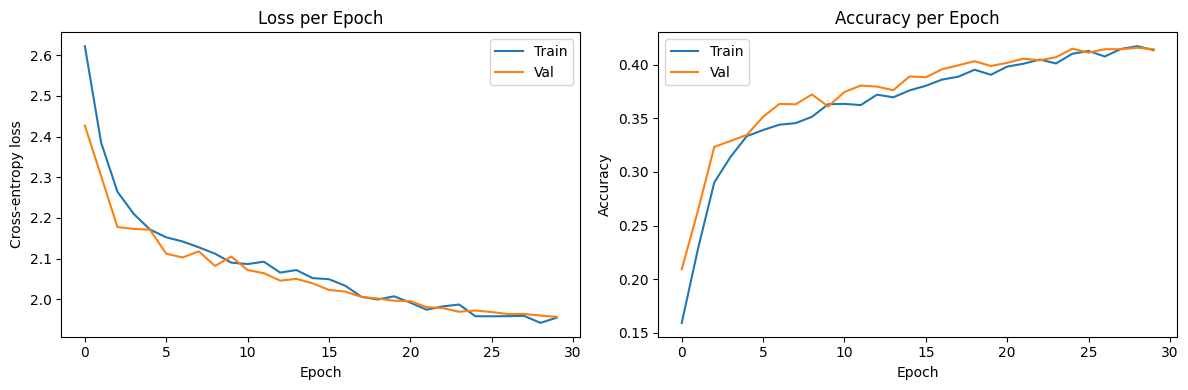

In [33]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'],   label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

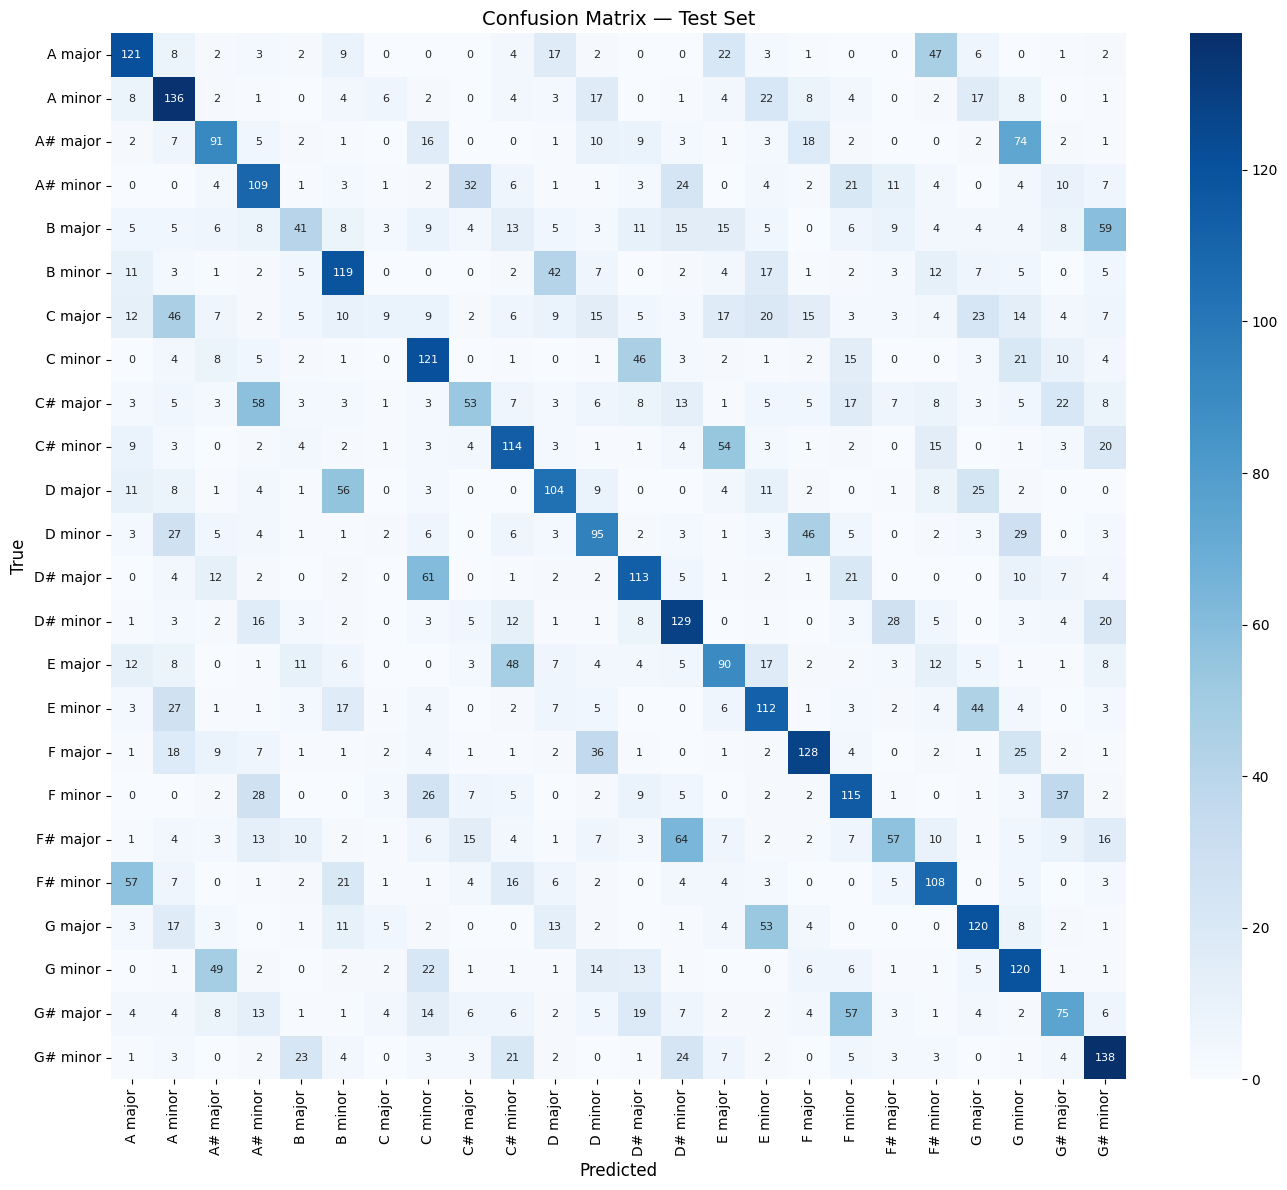

In [34]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes, ax=ax,
    annot_kws={'size': 8},
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True',      fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=14)
plt.tight_layout()
plt.show()

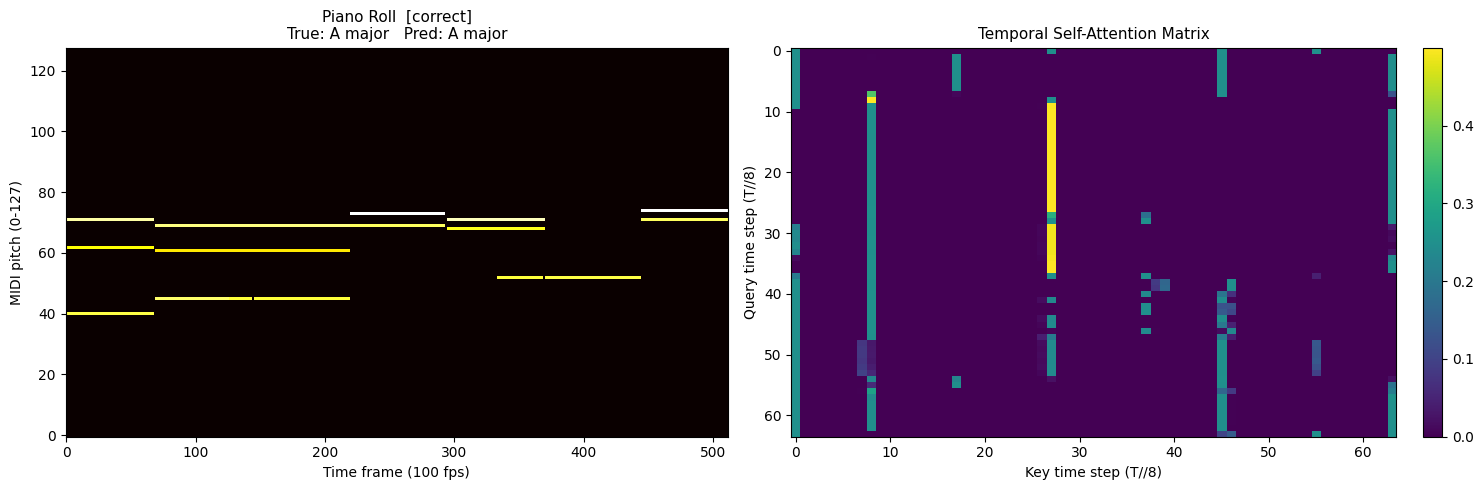

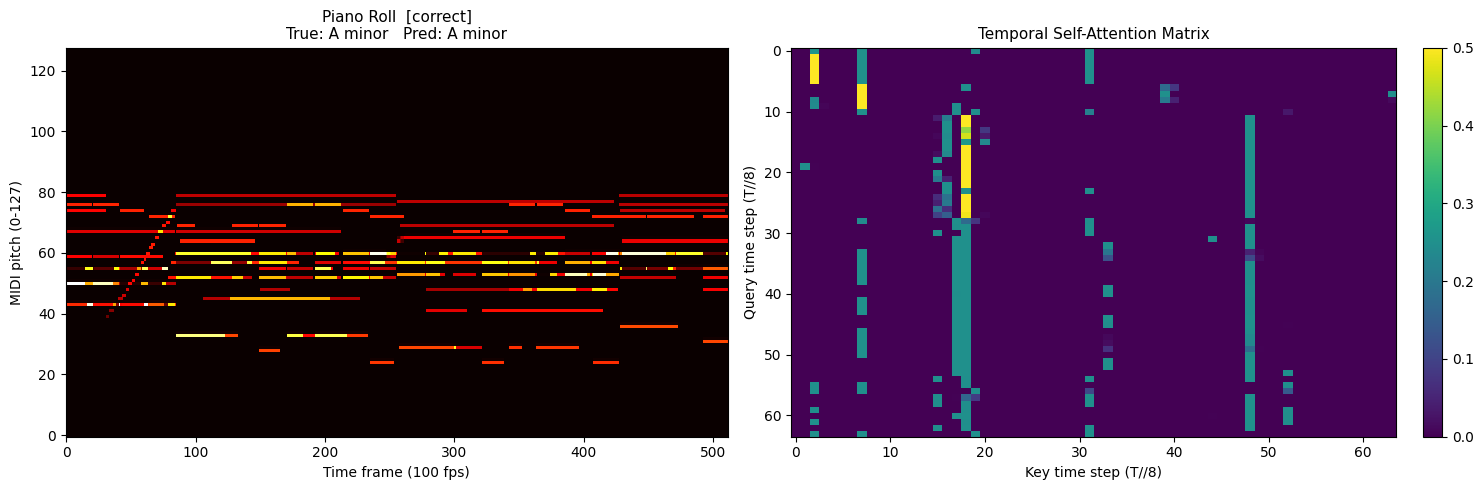

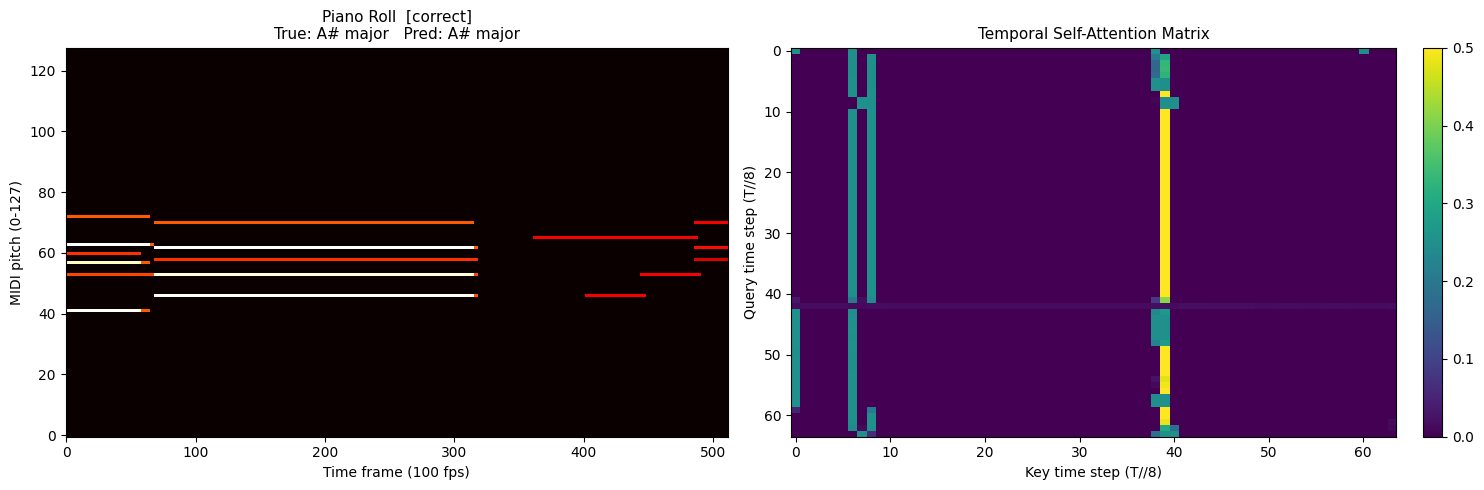

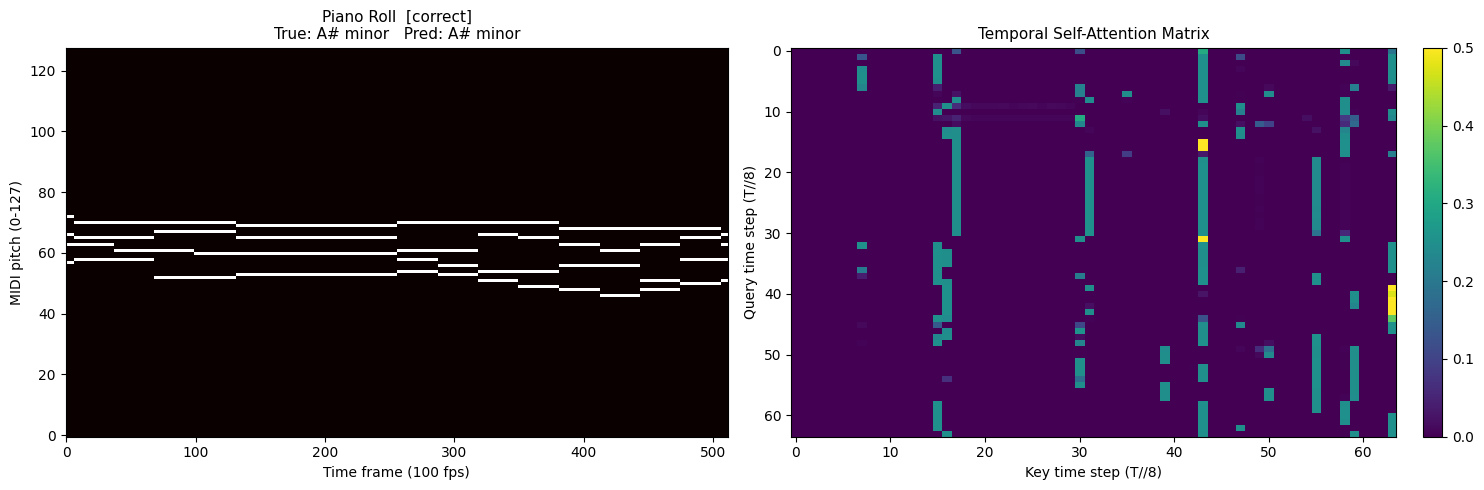

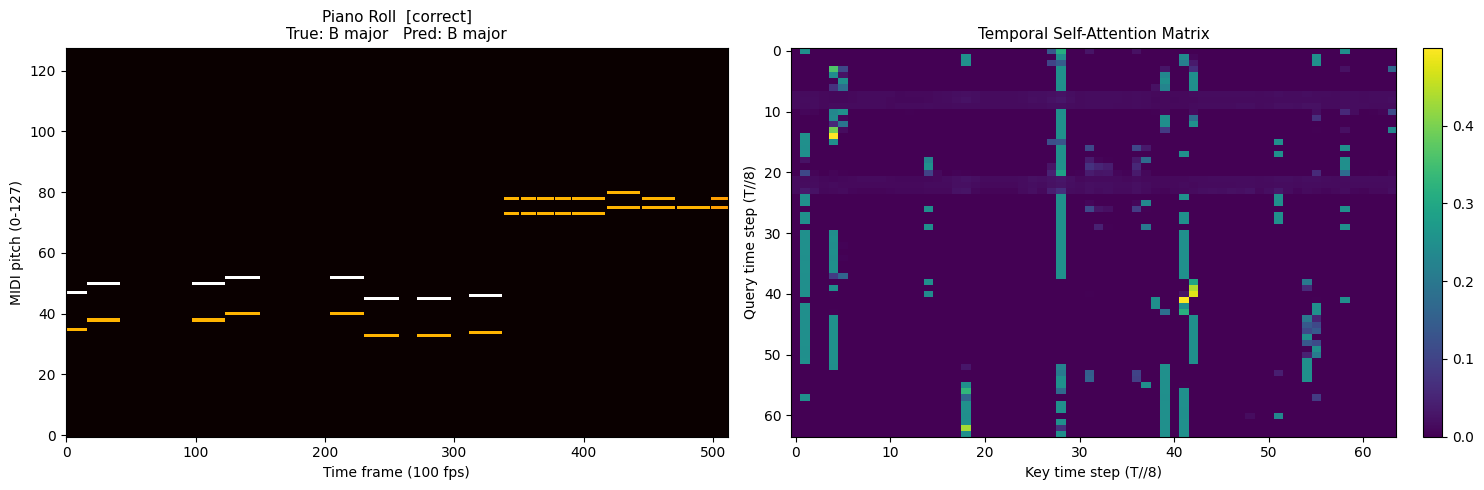

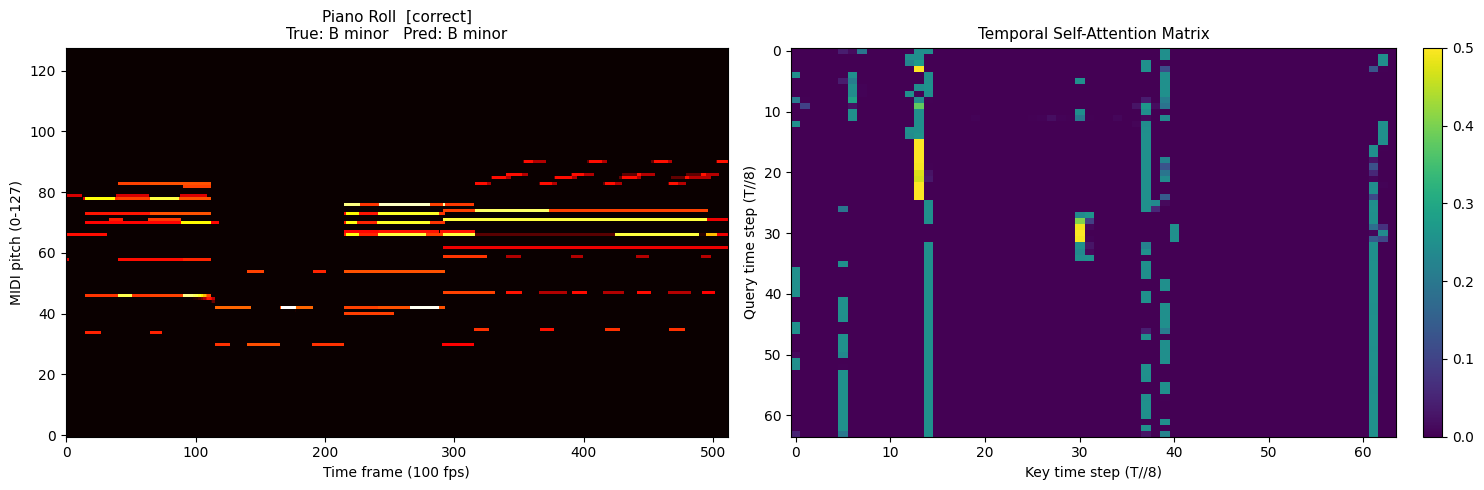

In [35]:
# ── Attention matrix visualisation ────────────────────────────────────────────
def visualize_attention(model: nn.Module, dataset: PianoRollDataset, idx: int) -> None:
    """Plot piano roll and temporal self-attention matrix for one test sample."""
    model.eval()
    x, true_label = dataset[idx]

    with torch.no_grad():
        logits, attn = model(x.unsqueeze(0).to(DEVICE), return_attention=True)

    pred_label = logits.argmax(dim=1).item()
    # attn: (1, T_steps, T_steps) — average over the batch dim
    attn_np = attn[0].cpu().float().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Piano roll — pitch vs time
    axes[0].imshow(x[0].numpy(), aspect='auto', origin='lower',
                   cmap='hot', interpolation='nearest')
    correct = 'correct' if true_label == pred_label else 'WRONG'
    axes[0].set_title(
        f'Piano Roll  [{correct}]\n'
        f'True: {classes[true_label]}   Pred: {classes[pred_label]}',
        fontsize=11,
    )
    axes[0].set_xlabel('Time frame (100 fps)')
    axes[0].set_ylabel('MIDI pitch (0-127)')

    # Temporal self-attention matrix
    im = axes[1].imshow(attn_np, aspect='auto', cmap='viridis', interpolation='nearest')
    axes[1].set_title('Temporal Self-Attention Matrix', fontsize=11)
    axes[1].set_xlabel('Key time step (T//8)')
    axes[1].set_ylabel('Query time step (T//8)')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# Show one correctly-classified example per key class (up to 6)
model.eval()
shown   = set()
correct_by_label = {lbl: [] for lbl in range(N_CLASSES)}
for i, (p, t) in enumerate(zip(all_preds, all_labels)):
    if p == t:
        correct_by_label[t].append(i)

# Map test-dataset index from the sorted correct list
test_df_reset = test_df.reset_index(drop=True)
for lbl in sorted(correct_by_label.keys()):
    if not correct_by_label[lbl]:
        continue
    visualize_attention(model, test_ds, correct_by_label[lbl][0])
    shown.add(lbl)
    if len(shown) >= 6:
        break